In [46]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

In [47]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f'Training data shape: {x_train.shape}')
print(f'Test data shape: {x_test.shape}')
print(f'Number of classes: {len(set(y_train.flatten()))}')

C:\A-Projects-gng\practicals\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Number of classes: 10


In [48]:
def build_model(dropout_rate=0.25, dense_units=128, learning_rate=0.001, l2_reg=0.0):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu',
                      input_shape=(32, 32, 3),
                      kernel_regularizer=regularizers.l2(l2_reg)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu',
                      kernel_regularizer=regularizers.l2(l2_reg)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu',
                      kernel_regularizer=regularizers.l2(l2_reg)),

        layers.Flatten(),
        layers.Dense(dense_units, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(dropout_rate),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [49]:
print("=== Baseline Model ===")

model_base = build_model(
    dropout_rate=0.0,
    dense_units=512,
    learning_rate=0.005,
    l2_reg=0.0
)

history_base = model_base.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

=== Baseline Model ===


C:\A-Projects-gng\practicals\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
625/625 - 57s - 91ms/step - accuracy: 0.3807 - loss: 1.6880 - val_accuracy: 0.4540 - val_loss: 1.4883
Epoch 2/10
625/625 - 40s - 64ms/step - accuracy: 0.5076 - loss: 1.3724 - val_accuracy: 0.5451 - val_loss: 1.2904
Epoch 3/10
625/625 - 39s - 62ms/step - accuracy: 0.5534 - loss: 1.2556 - val_accuracy: 0.5513 - val_loss: 1.2683
Epoch 4/10
625/625 - 37s - 59ms/step - accuracy: 0.5762 - loss: 1.2010 - val_accuracy: 0.5705 - val_loss: 1.2250
Epoch 5/10
625/625 - 38s - 60ms/step - accuracy: 0.5974 - loss: 1.1356 - val_accuracy: 0.5832 - val_loss: 1.2065
Epoch 6/10
625/625 - 37s - 59ms/step - accuracy: 0.6107 - loss: 1.0923 - val_accuracy: 0.5612 - val_loss: 1.2816
Epoch 7/10
625/625 - 37s - 59ms/step - accuracy: 0.6325 - loss: 1.0412 - val_accuracy: 0.5725 - val_loss: 1.2286
Epoch 8/10
625/625 - 37s - 60ms/step - accuracy: 0.6430 - loss: 1.0060 - val_accuracy: 0.5836 - val_loss: 1.2396
Epoch 9/10
625/625 - 37s - 59ms/step - accuracy: 0.6583 - loss: 0.9638 - val_accuracy: 0.5620 - 

In [50]:
print("=== Tuned Model ===")

model_tuned = build_model(
    dropout_rate=0.4,
    dense_units=256,
    learning_rate=0.001,
    l2_reg=0.0001
)

history_tuned = model_tuned.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

=== Tuned Model ===
Epoch 1/10
625/625 - 32s - 51ms/step - accuracy: 0.4048 - loss: 1.6414 - val_accuracy: 0.5248 - val_loss: 1.3522
Epoch 2/10
625/625 - 26s - 41ms/step - accuracy: 0.5483 - loss: 1.3084 - val_accuracy: 0.6053 - val_loss: 1.1792
Epoch 3/10
625/625 - 25s - 41ms/step - accuracy: 0.6085 - loss: 1.1623 - val_accuracy: 0.6352 - val_loss: 1.0854
Epoch 4/10
625/625 - 25s - 41ms/step - accuracy: 0.6520 - loss: 1.0585 - val_accuracy: 0.6622 - val_loss: 1.0206
Epoch 5/10
625/625 - 25s - 40ms/step - accuracy: 0.6861 - loss: 0.9763 - val_accuracy: 0.6828 - val_loss: 1.0088
Epoch 6/10
625/625 - 28s - 45ms/step - accuracy: 0.7111 - loss: 0.9149 - val_accuracy: 0.7004 - val_loss: 0.9461
Epoch 7/10
625/625 - 26s - 42ms/step - accuracy: 0.7311 - loss: 0.8653 - val_accuracy: 0.7168 - val_loss: 0.9155
Epoch 8/10
625/625 - 41s - 66ms/step - accuracy: 0.7515 - loss: 0.8182 - val_accuracy: 0.7251 - val_loss: 0.9119
Epoch 9/10
625/625 - 26s - 42ms/step - accuracy: 0.7673 - loss: 0.7738 - val

In [51]:
test_loss_base, test_acc_base = model_base.evaluate(x_test, y_test, verbose=0)
test_loss_tuned, test_acc_tuned = model_tuned.evaluate(x_test, y_test, verbose=0)

print(f'Baseline Model - Test Accuracy: {test_acc_base:.4f}, Loss: {test_loss_base:.4f}')
print(f'Tuned Model - Test Accuracy: {test_acc_tuned:.4f}, Loss: {test_loss_tuned:.4f}')

Baseline Model - Test Accuracy: 0.5714, Loss: 1.3152
Tuned Model - Test Accuracy: 0.7279, Loss: 0.9181


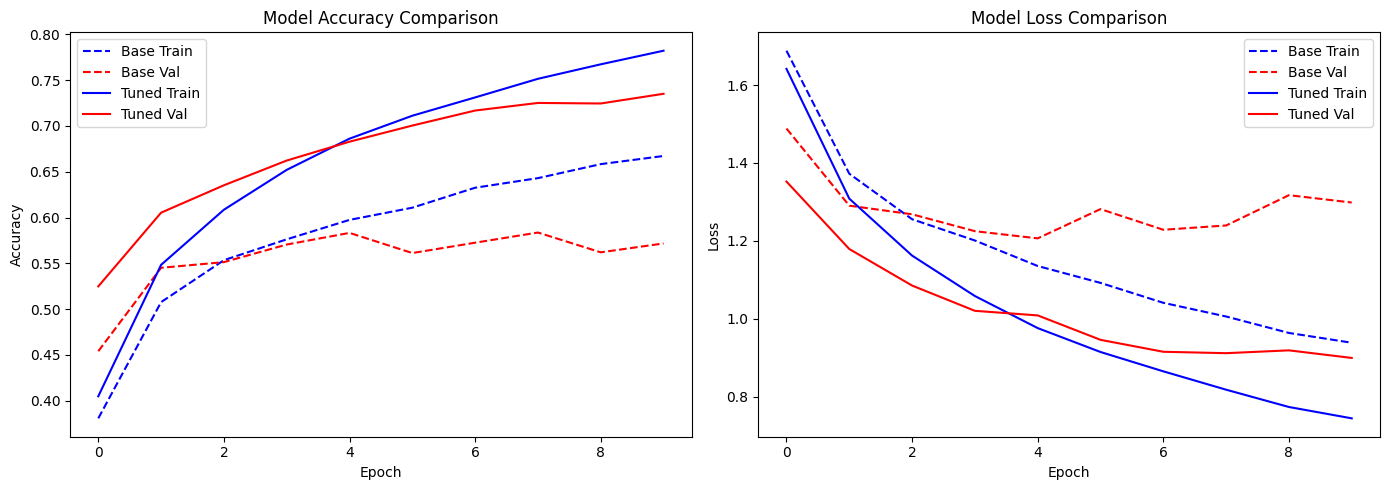

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history_base.history['accuracy'], 'b--', label='Base Train')
ax1.plot(history_base.history['val_accuracy'], 'r--', label='Base Val')
ax1.plot(history_tuned.history['accuracy'], 'b-', label='Tuned Train')
ax1.plot(history_tuned.history['val_accuracy'], 'r-', label='Tuned Val')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss
ax2.plot(history_base.history['loss'], 'b--', label='Base Train')
ax2.plot(history_base.history['val_loss'], 'r--', label='Base Val')
ax2.plot(history_tuned.history['loss'], 'b-', label='Tuned Train')
ax2.plot(history_tuned.history['val_loss'], 'r-', label='Tuned Val')
ax2.set_title('Model Loss Comparison')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

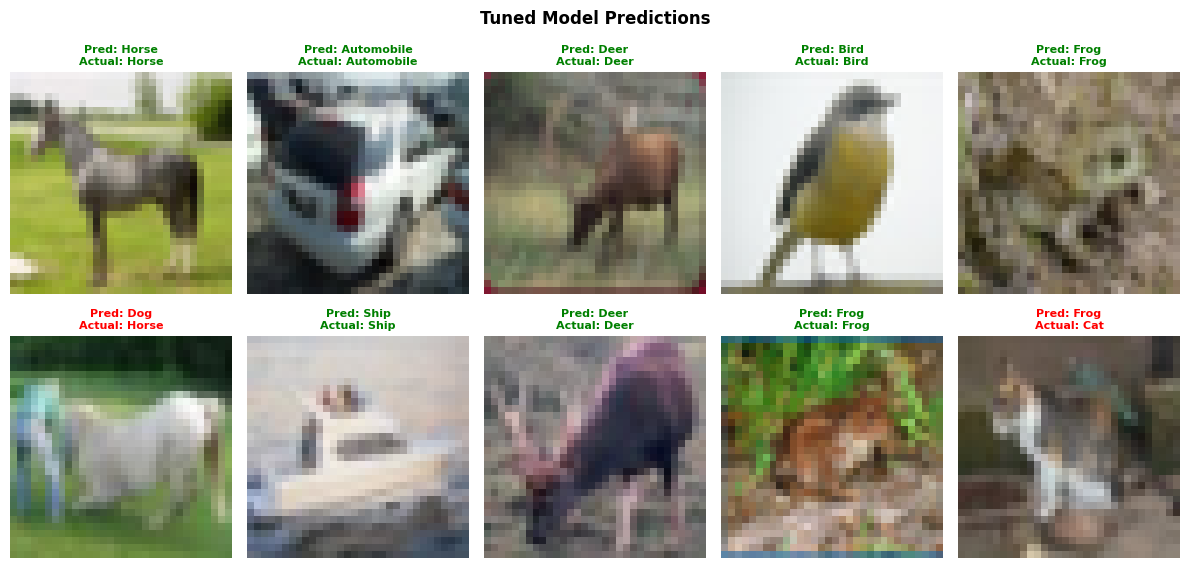

In [53]:
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

y_pred_tuned = np.argmax(model_tuned.predict(x_test, verbose=0), axis=1)
y_true = y_test.flatten()

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i in range(10):
    idx = np.random.randint(0, len(x_test))
    ax = axes[i//5, i%5]

    ax.imshow(x_test[idx])
    pred = class_names[y_pred_tuned[idx]]
    actual = class_names[y_true[idx]]

    color = 'green' if pred == actual else 'red'

    ax.set_title(f'Pred: {pred}\nActual: {actual}',
                 color=color, fontsize=8, fontweight='bold')
    ax.axis('off')

plt.suptitle('Tuned Model Predictions', fontweight='bold')
plt.tight_layout()
plt.show()